In [1]:
# Install required libraries (run once)
# !pip install lightgbm xgboost shap optuna imbalanced-learn plotly streamlit -q

In [2]:
import warnings
warnings.filterwarnings('ignore')

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle
import os

# Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE

# Models
import lightgbm as lgb
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest

# Explainability
import shap

# Hyperparameter tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [13]:
# ── Load both CSVs ────────────────────────────────────────────────────────────
# Update paths to match your local/Colab directory
transaction_path = 'train_transaction.csv'
identity_path    = 'train_identity.csv'

print('Loading transaction data...')
df_trans = pd.read_csv(transaction_path)
print(f'  Transactions shape: {df_trans.shape}')

print('Loading identity data...')
df_id = pd.read_csv(identity_path)
print(f'  Identity shape:     {df_id.shape}')

# ── Left merge on TransactionID ───────────────────────────────────────────────
df = df_trans.merge(df_id, on='TransactionID', how='left')
print(f'\nMerged dataset shape: {df.shape}')
print(f'Columns: {df.shape[1]} | Rows: {df.shape[0]:,}')

Loading transaction data...
  Transactions shape: (590540, 394)
Loading identity data...
  Identity shape:     (144233, 41)

Merged dataset shape: (590540, 434)
Columns: 434 | Rows: 590,540


In [14]:
# ── Basic info ────────────────────────────────────────────────────────────────
print('=== DATA TYPES SUMMARY ===')
print(df.dtypes.value_counts())
print(f'\nTotal columns: {df.shape[1]}')

print('\n=== FIRST 10 ROWS ===')
df.head(10)

=== DATA TYPES SUMMARY ===
float64    399
object      31
int64        4
Name: count, dtype: int64

Total columns: 434

=== FIRST 10 ROWS ===


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,...,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5000,W,13926,NaN,150.0000,discover,142.0000,credit,315.0000,87.0000,19.0000,NaN,NaN,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0000,W,2755,404.0000,150.0000,mastercard,102.0000,credit,325.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0000,W,4663,490.0000,150.0000,visa,166.0000,debit,330.0000,87.0000,287.0000,NaN,outlook.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0000,W,18132,567.0000,150.0000,mastercard,117.0000,debit,476.0000,87.0000,NaN,NaN,yahoo.com,NaN,2.0000,5.0000,0.0000,0.0000,0.0000,4.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0000,H,4497,514.0000,150.0000,mastercard,102.0000,credit,420.0000,87.0000,NaN,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,...,NotFound,166.0000,NaN,542.0000,144.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0000,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0000,W,5937,555.0000,150.0000,visa,226.0000,debit,272.0000,87.0000,36.0000,NaN,gmail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0000,W,12308,360.0000,150.0000,visa,166.0000,debit,126.0000,87.0000,0.0000,NaN,yahoo.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5000,W,12695,490.0000,150.0000,visa,226.0000,debit,325.0000,87.0000,NaN,NaN,mail.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0000,H,2803,100.0000,150.0000,visa,226.0000,debit,337.0000,87.0000,NaN,NaN,anonymous.com,NaN,1.0000,1.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,...,NotFound,166.0000,NaN,621.0000,500.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,iOS 11.1.2,mobile safari 11.0,32.0000,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0000,W,17399,111.0000,150.0000,mastercard,224.0000,debit,204.0000,87.0000,19.0000,NaN,yahoo.com,NaN,2.0000,2.0000,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


=== CLASS DISTRIBUTION ===
          Count  Percentage
isFraud                    
0        569877     96.5000
1         20663      3.5000

Fraud-to-legit ratio: 1 : 27.6


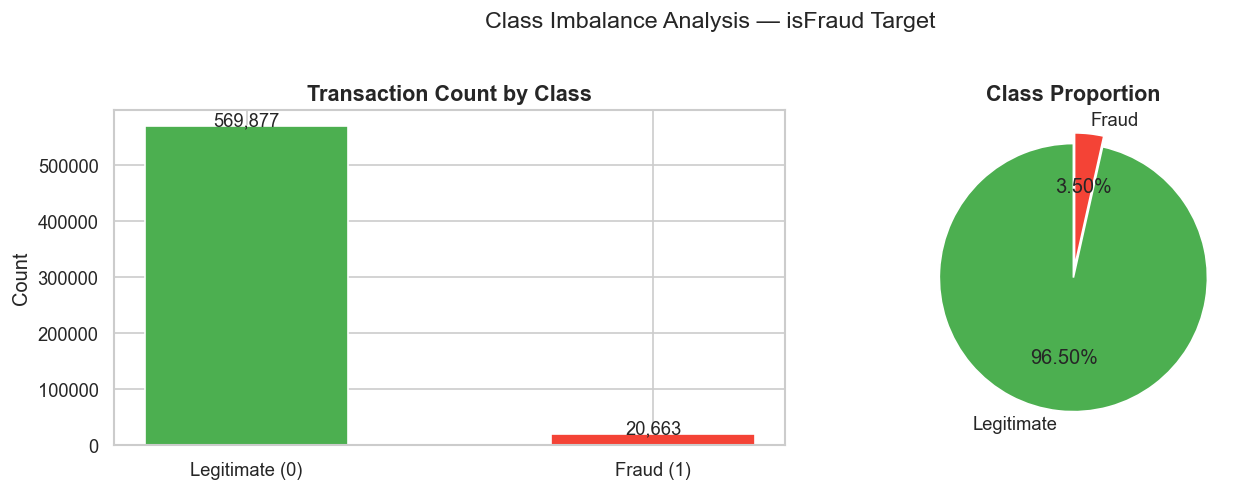

In [15]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print('=== CLASS DISTRIBUTION ===')
print(pd.DataFrame({'Count': fraud_counts, 'Percentage': fraud_pct.round(2)}))
print(f'\nFraud-to-legit ratio: 1 : {fraud_counts[0]/fraud_counts[1]:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', width=0.5)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            autopct='%1.2f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, explode=(0, 0.08))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Class Imbalance Analysis — isFraud Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('class_imbalance.png', bbox_inches='tight', dpi=150)
plt.show()

Columns with missing values: 414 / 434
Columns with >50% missing:   214
Columns with >80% missing:   74


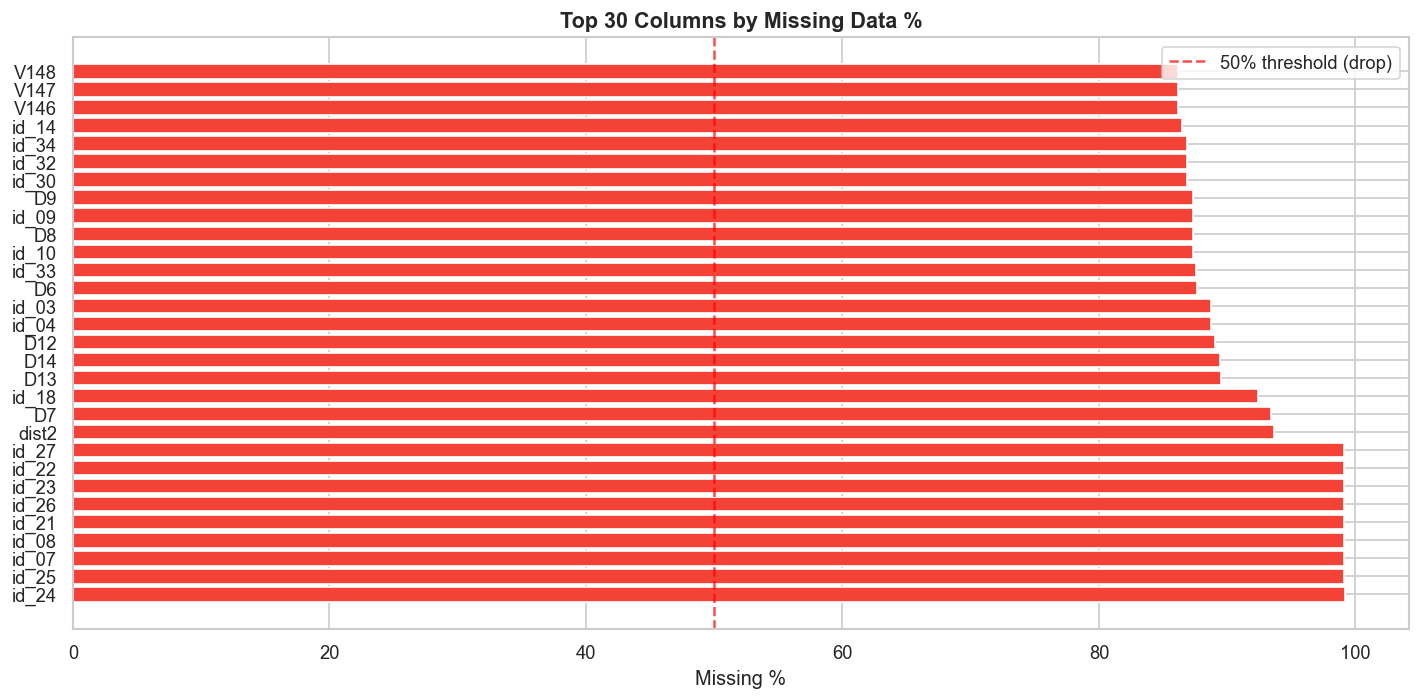

In [16]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)} / {df.shape[1]}')
print(f'Columns with >50% missing:   {(missing_pct > 50).sum()}')
print(f'Columns with >80% missing:   {(missing_pct > 80).sum()}')

# Plot top 30 missing columns
top_missing = missing_df.head(30)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#F44336' if x > 50 else '#FF9800' if x > 20 else '#2196F3'
          for x in top_missing['Missing %']]
ax.barh(top_missing.index, top_missing['Missing %'], color=colors)
ax.axvline(50, color='red', linestyle='--', alpha=0.7, label='50% threshold (drop)')
ax.set_xlabel('Missing %')
ax.set_title('Top 30 Columns by Missing Data %', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

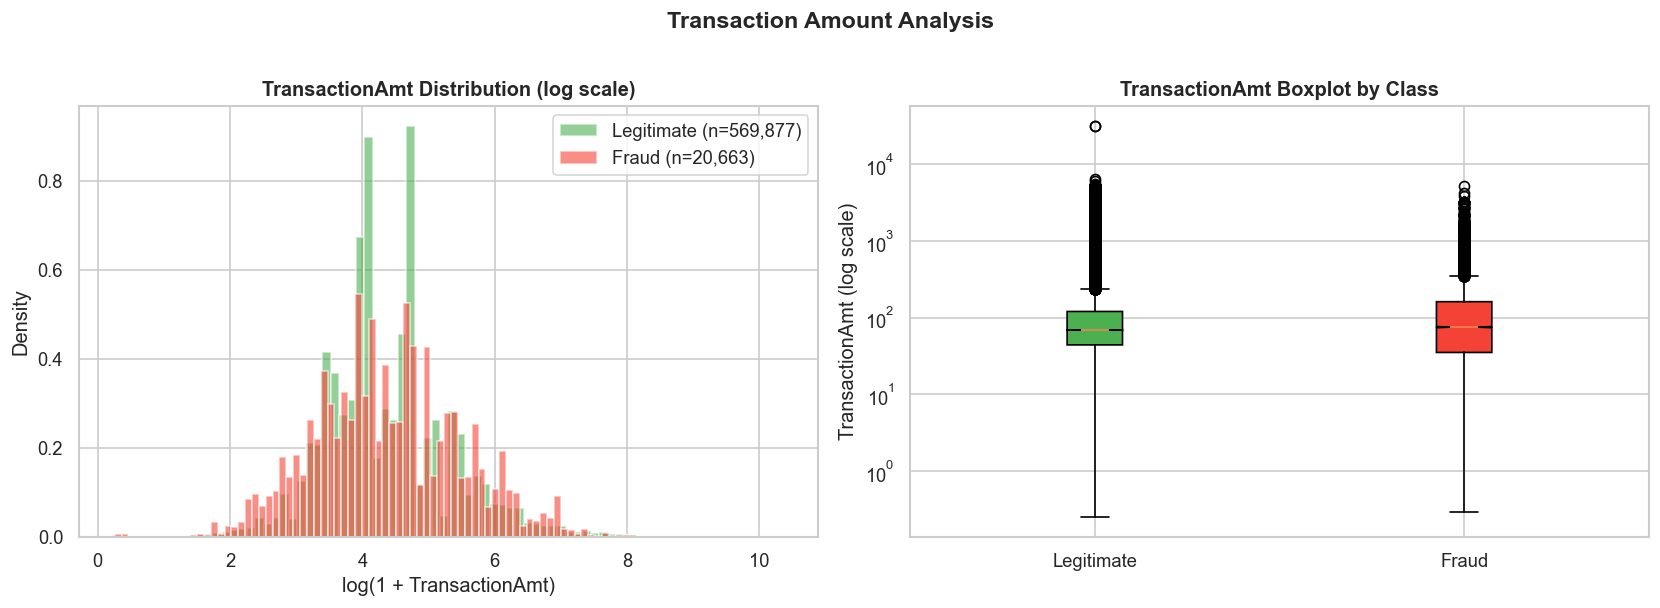

              count     mean      std    min     25%     50%      75%  \
isFraud                                                                 
0       569877.0000 134.5100 239.4000 0.2500 43.9700 68.5000 120.0000   
1        20663.0000 149.2400 232.2100 0.2900 35.0400 75.0000 161.0000   

               max  
isFraud             
0       31937.3900  
1        5191.0000  


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-scale histogram
for label, color in [(0, '#4CAF50'), (1, '#F44336')]:
    subset = df[df['isFraud'] == label]['TransactionAmt']
    axes[0].hist(np.log1p(subset), bins=80, alpha=0.6, color=color,
                 label=f'{"Fraud" if label else "Legitimate"} (n={len(subset):,})', density=True)
axes[0].set_xlabel('log(1 + TransactionAmt)')
axes[0].set_ylabel('Density')
axes[0].set_title('TransactionAmt Distribution (log scale)', fontsize=12, fontweight='bold')
axes[0].legend()

# Box plot
data_plot = [
    df[df['isFraud'] == 0]['TransactionAmt'].values,
    df[df['isFraud'] == 1]['TransactionAmt'].values
]
bp = axes[1].boxplot(data_plot, labels=['Legitimate', 'Fraud'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_yscale('log')
axes[1].set_ylabel('TransactionAmt (log scale)')
axes[1].set_title('TransactionAmt Boxplot by Class', fontsize=12, fontweight='bold')

plt.suptitle('Transaction Amount Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('transaction_amt_dist.png', bbox_inches='tight', dpi=150)
plt.show()

# Summary stats
print(df.groupby('isFraud')['TransactionAmt'].describe().round(2))

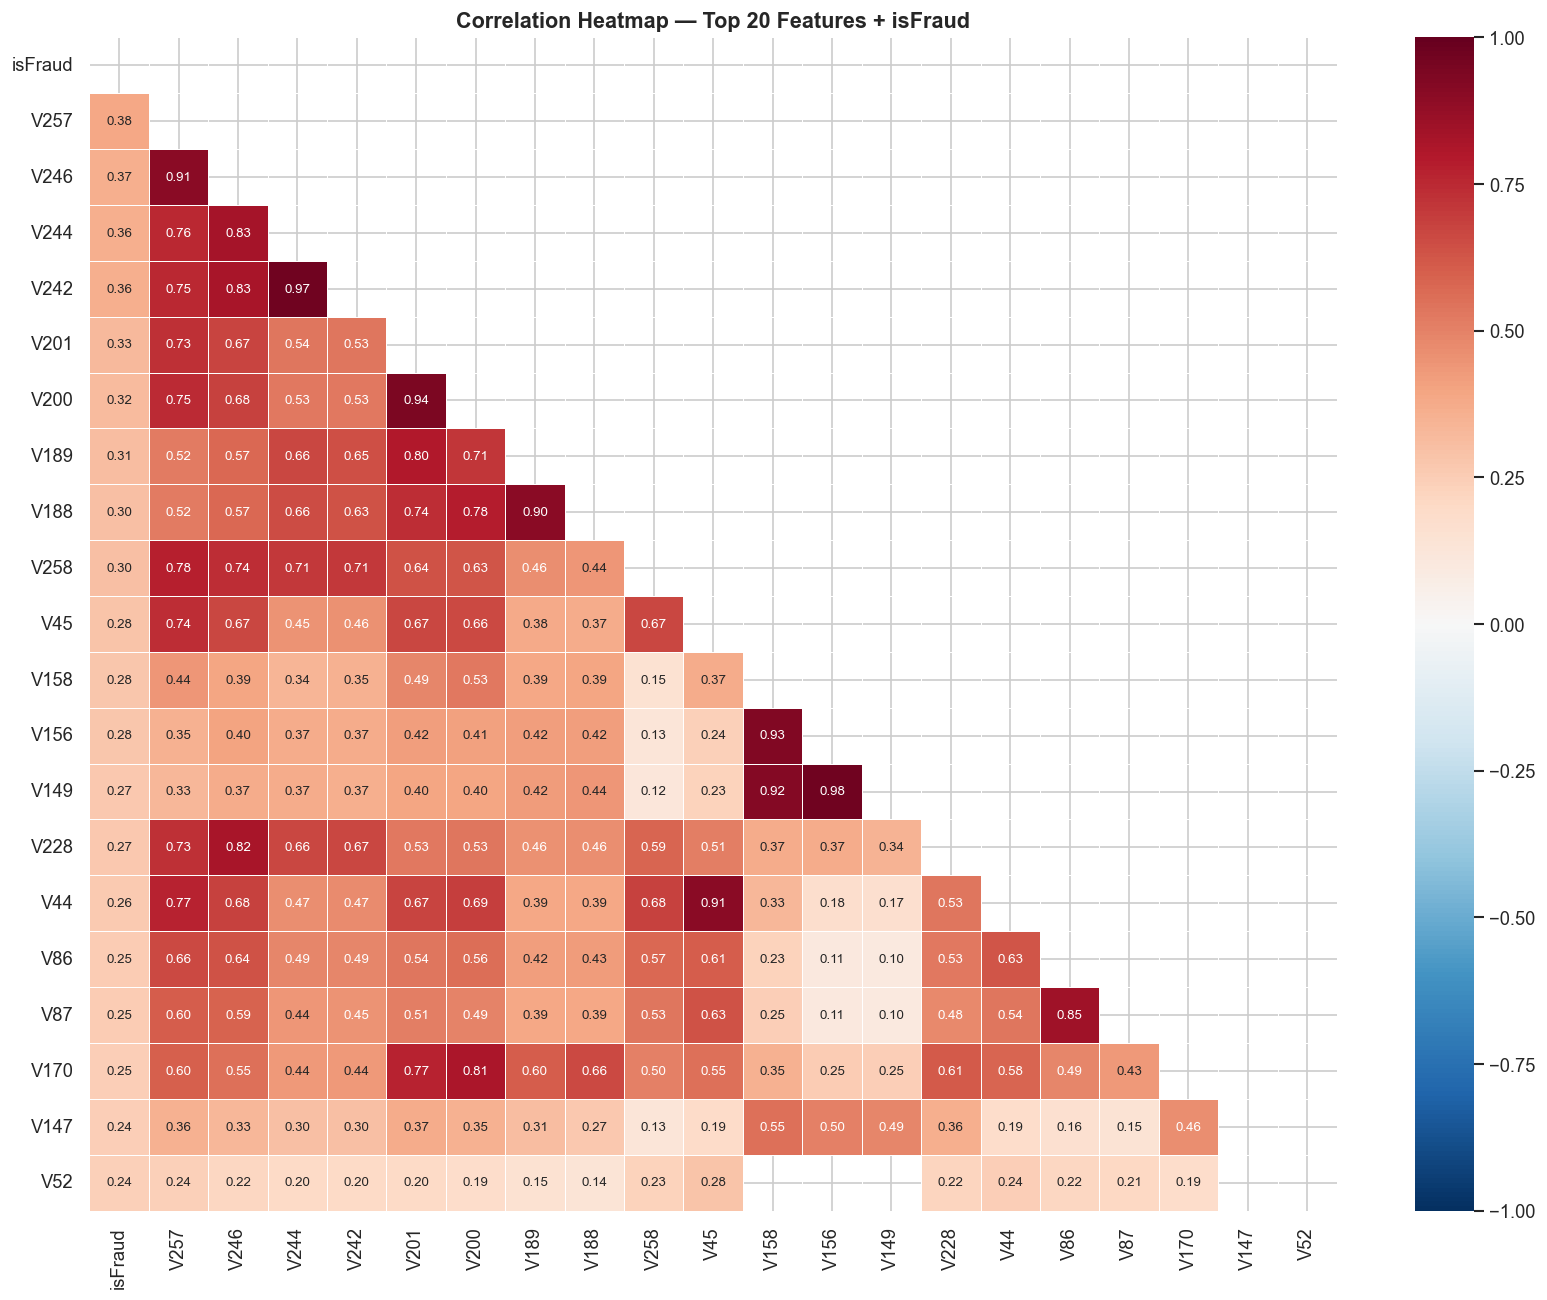

In [18]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Rank by absolute correlation with isFraud, take top 20
corr_with_target = df[num_cols].corr()['isFraud'].abs().sort_values(ascending=False)
top20 = corr_with_target.head(21).index.tolist()  # includes isFraud itself

corr_matrix = df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            annot_kws={'size': 8}, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 20 Features + isFraud', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

In [19]:
MISSING_THRESHOLD = 0.50

missing_pct = df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > MISSING_THRESHOLD].index.tolist()

print(f'Dropping {len(cols_to_drop)} columns with >{MISSING_THRESHOLD*100:.0f}% missing values')
df = df.drop(columns=cols_to_drop)
print(f'Remaining shape: {df.shape}')

Dropping 214 columns with >50% missing values
Remaining shape: (590540, 220)


In [20]:
# ── Feature Engineering ───────────────────────────────────────────────────────

# 1. Time-based features from TransactionDT (seconds from reference point)
df['HourOfDay']   = (df['TransactionDT'] // 3600) % 24
df['DayOfWeek']   = (df['TransactionDT'] // 86400) % 7

# 2. Amount features
mean_amt = df['TransactionAmt'].mean()
df['AmtToMeanRatio']  = df['TransactionAmt'] / mean_amt
df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])
df['AmtDecimalPart']  = df['TransactionAmt'] - df['TransactionAmt'].astype(int)

# 3. Risk flag
df['IsNightTransaction'] = df['HourOfDay'].apply(lambda h: 1 if (h >= 23 or h <= 5) else 0)

new_features = ['HourOfDay', 'DayOfWeek', 'AmtToMeanRatio',
                'LogTransactionAmt', 'AmtDecimalPart', 'IsNightTransaction']
print('New features added:')
print(df[new_features].describe().round(4))

New features added:
        HourOfDay   DayOfWeek  AmtToMeanRatio  LogTransactionAmt  \
count 590540.0000 590540.0000     590540.0000        590540.0000   
mean      13.8619      2.9579          1.0000             4.3830   
std        7.6072      2.0340          1.7712             0.9372   
min        0.0000      0.0000          0.0019             0.2239   
25%        6.0000      1.0000          0.3208             3.7915   
50%       16.0000      3.0000          0.5093             4.2452   
75%       20.0000      5.0000          0.9257             4.8363   
max       23.0000      6.0000        236.5257            10.3716   

       AmtDecimalPart  IsNightTransaction  
count     590540.0000         590540.0000  
mean           0.3795              0.3092  
std            0.4341              0.4622  
min            0.0000              0.0000  
25%            0.0000              0.0000  
50%            0.0000              0.0000  
75%            0.9500              1.0000  
max            

In [21]:
# ── Separate feature types ────────────────────────────────────────────────────
TARGET = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT']

df_model = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

num_cols  = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols  = [c for c in num_cols if c != TARGET]
cat_cols  = df_model.select_dtypes(include=['object']).columns.tolist()

print(f'Numerical features:   {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

# ── Impute numerical ─────────────────────────────────────────────────────────
for col in num_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# ── Impute & encode categorical ───────────────────────────────────────────────
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('\nMissing values after imputation:', df_model.isnull().sum().sum())
print(f'Final feature count: {df_model.shape[1] - 1} (+ target)')

Numerical features:   214
Categorical features: 9

Missing values after imputation: 0
Final feature count: 223 (+ target)


In [22]:
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

print('=== PRE-SMOTE CLASS DISTRIBUTION ===')
print(pd.Series(y_train).value_counts().rename({0:'Legitimate', 1:'Fraud'}))
print(f'Fraud rate (train): {y_train.mean()*100:.2f}%')

# ── Scale BEFORE SMOTE ────────────────────────────────────────────────────────
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Apply SMOTE on TRAINING SET ONLY ──────────────────────────────────────────
# k_neighbors=5 is default; use minority_class_count-1 if very small minority
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('\n=== POST-SMOTE CLASS DISTRIBUTION ===')
print(pd.Series(y_train_sm).value_counts().rename({0:'Legitimate', 1:'Fraud'}))
print(f'Fraud rate (after SMOTE): {y_train_sm.mean()*100:.2f}%')
print(f'\nTraining set size: {len(y_train):,} → {len(y_train_sm):,} after SMOTE')
print(f'Test set size (unchanged): {len(y_test):,}')

# Save scaler and feature names for Streamlit
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(X.columns.tolist(), open('feature_names.pkl', 'wb'))

=== PRE-SMOTE CLASS DISTRIBUTION ===
isFraud
Legitimate    455902
Fraud          16530
Name: count, dtype: int64
Fraud rate (train): 3.50%

=== POST-SMOTE CLASS DISTRIBUTION ===
isFraud
Legitimate    455902
Fraud         455902
Name: count, dtype: int64
Fraud rate (after SMOTE): 50.00%

Training set size: 472,432 → 911,804 after SMOTE
Test set size (unchanged): 118,108


In [23]:
def evaluate_model(name, y_true, y_pred_proba, y_pred_class, threshold=0.5):
    """Compute and print all evaluation metrics."""
    metrics = {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred_class), 4),
        'Precision': round(precision_score(y_true, y_pred_class, zero_division=0), 4),
        'Recall':    round(recall_score(y_true, y_pred_class, zero_division=0), 4),
        'F1':        round(f1_score(y_true, y_pred_class, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_pred_proba), 4),
        'PR-AUC':    round(average_precision_score(y_true, y_pred_proba), 4),
    }
    return metrics


def plot_confusion_matrix(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')


results = []  # Will collect metric dicts from all models
model_probas = {}  # Store probabilities for curve plots

print('Helper functions ready.')

Helper functions ready.


In [24]:
print('Training LightGBM...')

lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_scaled, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(period=-1)]
)

lgbm_proba = lgbm.predict_proba(X_test_scaled)[:, 1]
lgbm_pred  = (lgbm_proba >= 0.5).astype(int)

res_lgbm = evaluate_model('LightGBM', y_test, lgbm_proba, lgbm_pred)
results.append(res_lgbm)
model_probas['LightGBM'] = lgbm_proba

print(f"LightGBM → ROC-AUC: {res_lgbm['ROC-AUC']} | PR-AUC: {res_lgbm['PR-AUC']} | F1: {res_lgbm['F1']}")

# Save model
pickle.dump(lgbm, open('lgbm_model.pkl', 'wb'))

Training LightGBM...
LightGBM → ROC-AUC: 0.7907 | PR-AUC: 0.1074 | F1: 0.0836


In [25]:
print('Training XGBoost...')

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_proba = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_pred  = (xgb_proba >= 0.5).astype(int)

res_xgb = evaluate_model('XGBoost', y_test, xgb_proba, xgb_pred)
results.append(res_xgb)
model_probas['XGBoost'] = xgb_proba

print(f"XGBoost → ROC-AUC: {res_xgb['ROC-AUC']} | PR-AUC: {res_xgb['PR-AUC']} | F1: {res_xgb['F1']}")

pickle.dump(xgb, open('xgb_model.pkl', 'wb'))

Training XGBoost...
XGBoost → ROC-AUC: 0.9243 | PR-AUC: 0.5913 | F1: 0.2829


In [26]:
print('Training Isolation Forest...')

# Isolation Forest is unsupervised — train on full X_train_scaled (no SMOTE needed)
iforest = IsolationForest(
    n_estimators=200,
    contamination=0.035,   # ~3.5% expected fraud rate
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iforest.fit(X_train_scaled)

# Convert decision_function scores to [0,1] pseudo-probability (lower score = more anomalous)
if_scores = iforest.decision_function(X_test_scaled)
if_proba  = 1 - (if_scores - if_scores.min()) / (if_scores.max() - if_scores.min())
if_pred   = (iforest.predict(X_test_scaled) == -1).astype(int)  # -1 = anomaly = fraud

res_if = evaluate_model('Isolation Forest', y_test, if_proba, if_pred)
results.append(res_if)
model_probas['Isolation Forest'] = if_proba

print(f"Isolation Forest → ROC-AUC: {res_if['ROC-AUC']} | PR-AUC: {res_if['PR-AUC']} | F1: {res_if['F1']}")

Training Isolation Forest...
Isolation Forest → ROC-AUC: 0.7229 | PR-AUC: 0.1174 | F1: 0.1999


In [27]:
results_df = pd.DataFrame(results).set_index('Model')
print('=== MODEL COMPARISON ===')
display(results_df.style.highlight_max(axis=0, color='#d4edda').format('{:.4f}'))

=== MODEL COMPARISON ===


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM,0.2511,0.0437,0.9758,0.0836,0.7907,0.1074
XGBoost,0.8490,0.1697,0.8514,0.2829,0.9243,0.5913
Isolation Forest,0.9439,0.1996,0.2001,0.1999,0.7229,0.1174


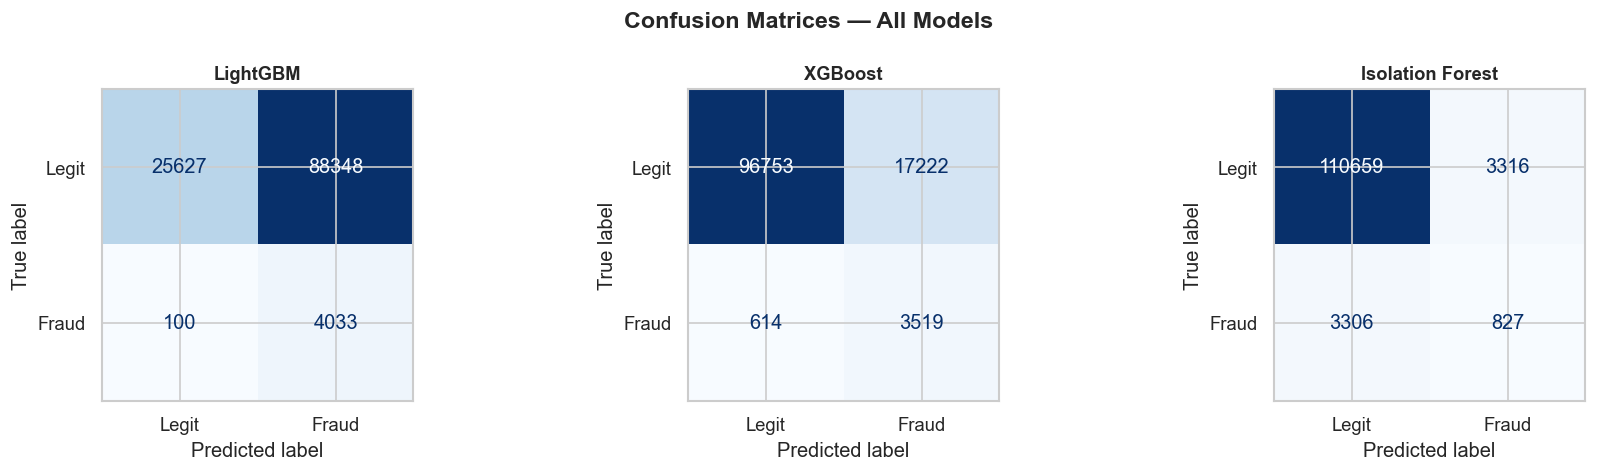

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_confusion_matrix(y_test, lgbm_pred,  'LightGBM',         axes[0])
plot_confusion_matrix(y_test, xgb_pred,   'XGBoost',          axes[1])
plot_confusion_matrix(y_test, if_pred,    'Isolation Forest', axes[2])

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

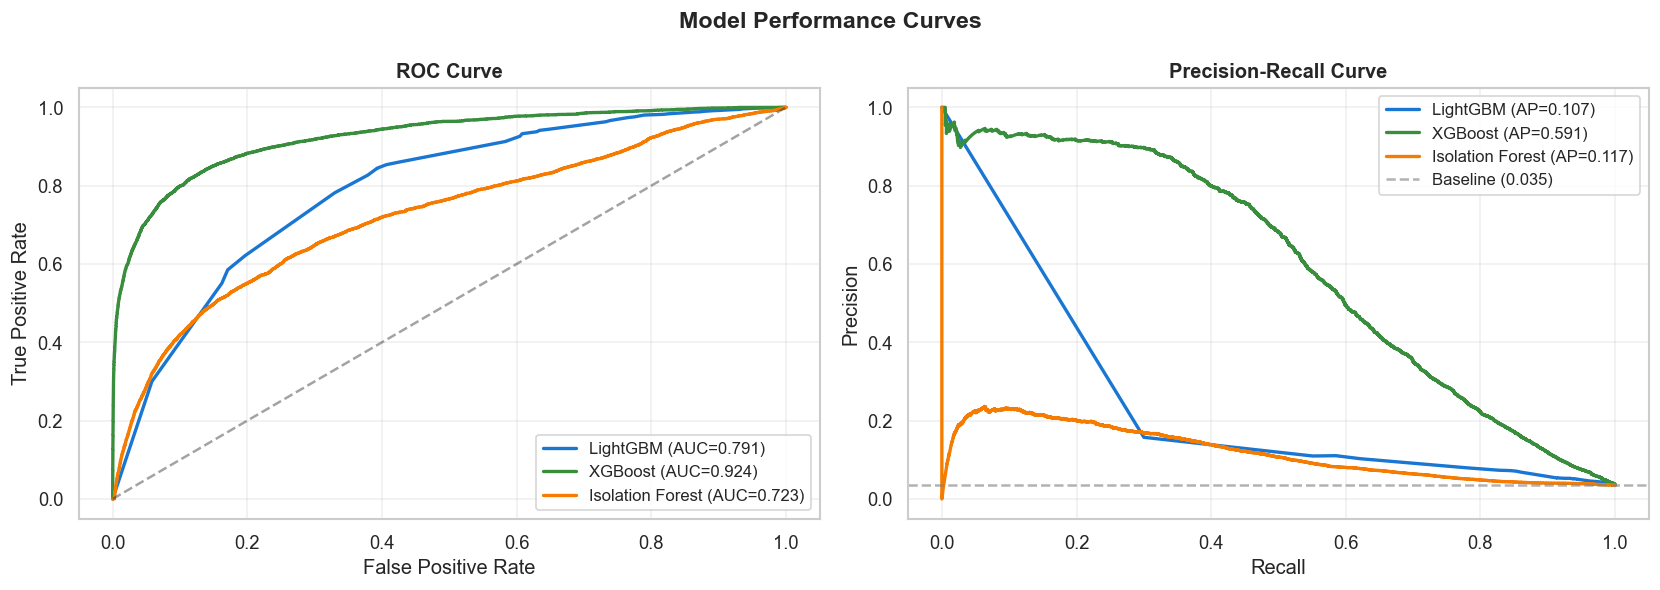

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#1976D2', '#388E3C', '#F57C00']

for (name, proba), color in zip(model_probas.items(), colors):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

    # PR Curve
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f'{name} (AP={pr_auc:.3f})')

# ROC plot formatting
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)

# PR plot formatting
baseline = y_test.mean()
axes[1].axhline(baseline, color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({baseline:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

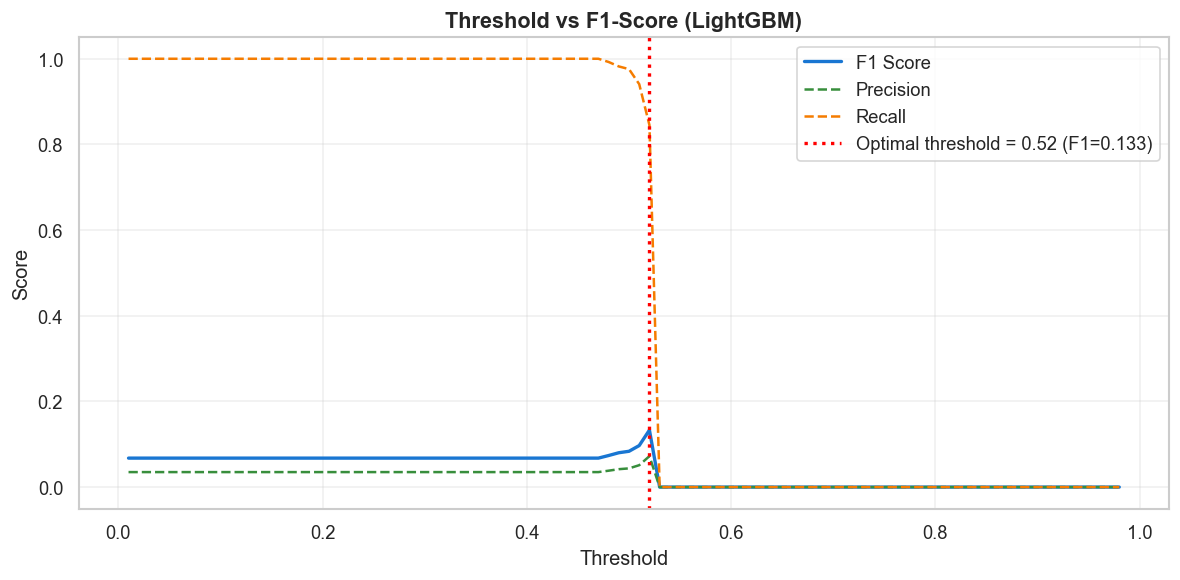

Optimal threshold: 0.52
Best F1 Score:     0.1331

Optimized LightGBM Metrics:


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM (Optimal Threshold),0.6148,0.0722,0.8451,0.1331,0.7907,0.1074


In [30]:
thresholds = np.arange(0.01, 0.99, 0.01)
f1_scores  = [f1_score(y_test, (lgbm_proba >= t).astype(int), zero_division=0) for t in thresholds]
precision_scores = [precision_score(y_test, (lgbm_proba >= t).astype(int), zero_division=0) for t in thresholds]
recall_scores    = [recall_score(y_test, (lgbm_proba >= t).astype(int), zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, f1_scores,        label='F1 Score',  color='#1976D2', lw=2)
ax.plot(thresholds, precision_scores, label='Precision', color='#388E3C', lw=1.5, linestyle='--')
ax.plot(thresholds, recall_scores,    label='Recall',    color='#F57C00', lw=1.5, linestyle='--')
ax.axvline(best_threshold, color='red', linestyle=':', lw=2,
           label=f'Optimal threshold = {best_threshold:.2f} (F1={best_f1:.3f})')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.set_title('Threshold vs F1-Score (LightGBM)', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_optimization.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'Optimal threshold: {best_threshold:.2f}')
print(f'Best F1 Score:     {best_f1:.4f}')

# Re-predict with optimal threshold
lgbm_pred_opt = (lgbm_proba >= best_threshold).astype(int)
res_lgbm_opt  = evaluate_model('LightGBM (Optimal Threshold)', y_test, lgbm_proba, lgbm_pred_opt)
print('\nOptimized LightGBM Metrics:')
pd.DataFrame([res_lgbm_opt]).set_index('Model')

In [31]:
def optuna_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 200, 800),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 10),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 150),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'scale_pos_weight':  (y_train == 0).sum() / (y_train == 1).sum(),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_train_sm, y_train_sm)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    return average_precision_score(y_test, proba)


print('Running Optuna tuning (50 trials)...')
study = optuna.create_study(direction='maximize')
study.optimize(optuna_objective, n_trials=50, show_progress_bar=True)

print(f'\nBest PR-AUC: {study.best_value:.4f}')
print(f'Best params:\n{study.best_params}')

Running Optuna tuning (50 trials)...


Best trial: 47. Best value: 0.801564: 100%|██████████| 50/50 [1:21:04<00:00, 97.28s/it] 


Best PR-AUC: 0.8016
Best params:
{'n_estimators': 779, 'learning_rate': 0.19898849004041888, 'max_depth': 8, 'num_leaves': 141, 'min_child_samples': 12, 'subsample': 0.5699822403763014, 'colsample_bytree': 0.9324400416667818, 'reg_alpha': 1.8248088020032622, 'reg_lambda': 0.00045013927008333315}


In [32]:
# ── Retrain with best params ──────────────────────────────────────────────────
best_params = study.best_params
best_params.update({'scale_pos_weight': (y_train==0).sum()/(y_train==1).sum(),
                    'random_state': 42, 'n_jobs': -1, 'verbose': -1})

lgbm_tuned = lgb.LGBMClassifier(**best_params)
lgbm_tuned.fit(X_train_sm, y_train_sm)

tuned_proba = lgbm_tuned.predict_proba(X_test_scaled)[:, 1]
tuned_pred  = (tuned_proba >= best_threshold).astype(int)

res_tuned = evaluate_model('LightGBM (Tuned)', y_test, tuned_proba, tuned_pred)
print('Tuned model results:')
pd.DataFrame([res_tuned]).set_index('Model')

# Overwrite saved model with tuned version
pickle.dump(lgbm_tuned, open('lgbm_model.pkl', 'wb'))
print('\nTuned model saved to lgbm_model.pkl')

Tuned model results:

Tuned model saved to lgbm_model.pkl


Computing SHAP values...
SHAP values shape: (500, 223)


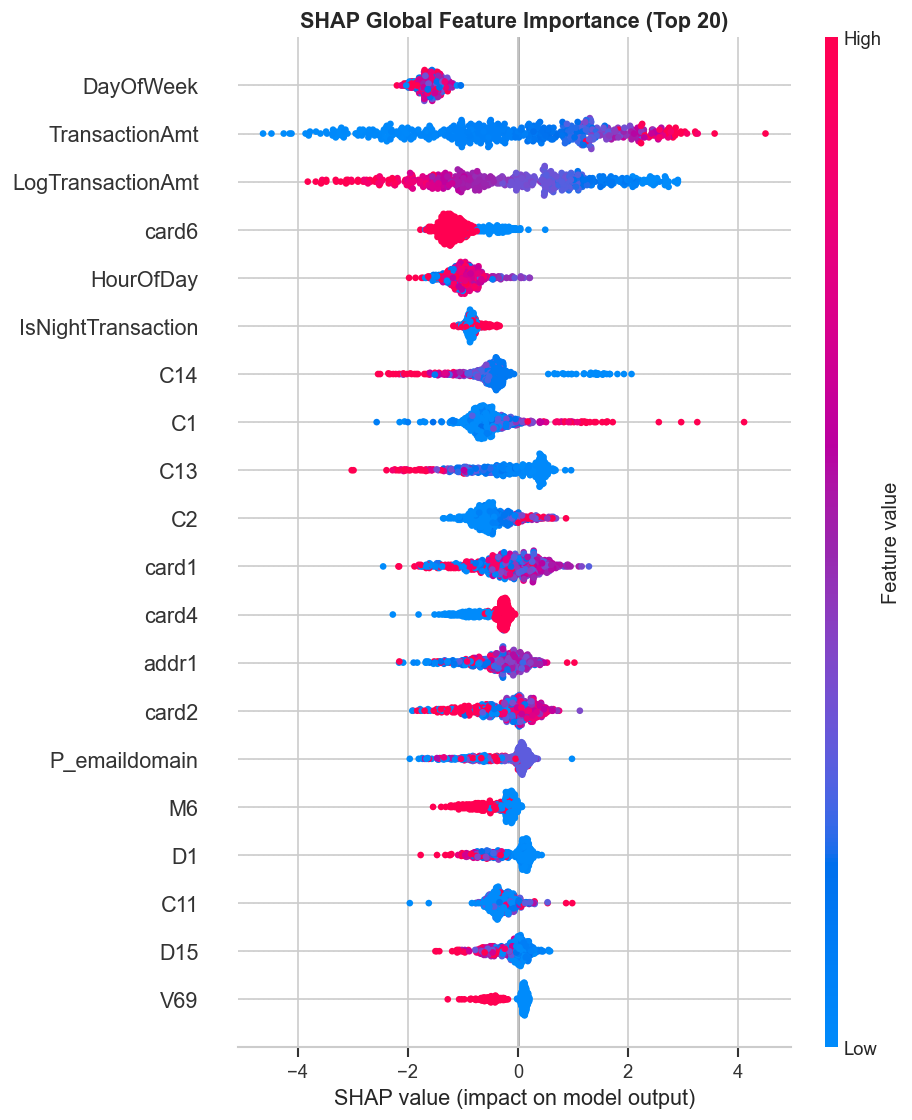

Explainer saved.


In [34]:
print('Computing SHAP values...')
explainer = shap.TreeExplainer(lgbm_tuned)

SHAP_SAMPLE = 500
X_test_df   = pd.DataFrame(X_test_scaled, columns=X.columns)
X_shap      = X_test_df.sample(SHAP_SAMPLE, random_state=42)

shap_values = explainer.shap_values(X_shap)

# ── Handle all SHAP output formats ───────────────────────────────────────────
if isinstance(shap_values, list):
    sv_fraud = shap_values[1]                  # old format
elif len(shap_values.shape) == 3:
    sv_fraud = shap_values[:, :, 1]            # new 3D format
else:
    sv_fraud = shap_values                     # already 2D

print(f'SHAP values shape: {sv_fraud.shape}')

# ── Global Summary Plot ───────────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_fraud, X_shap, max_display=20, show=False)
plt.title('SHAP Global Feature Importance (Top 20)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight', dpi=150)
plt.show()

# ── Save explainer ────────────────────────────────────────────────────────────
pickle.dump(explainer, open('shap_explainer.pkl', 'wb'))
print('Explainer saved.')

In [35]:
# ── Find 3 representative cases ───────────────────────────────────────────────
test_probas = lgbm_tuned.predict_proba(X_test_scaled)[:, 1]
test_df_idx = pd.DataFrame({'prob': test_probas, 'true': y_test.values})

# Case 1: Confirmed fraud (high probability & actually fraud)
fraud_mask  = test_df_idx['true'] == 1
idx_fraud   = test_df_idx[fraud_mask].nlargest(1, 'prob').index[0]

# Case 2: Borderline (~0.50 probability)
idx_border  = (test_df_idx['prob'] - 0.50).abs().idxmin()

# Case 3: Legitimate (low probability & actually legit)
legit_mask  = test_df_idx['true'] == 0
idx_legit   = test_df_idx[legit_mask].nsmallest(1, 'prob').index[0]

cases = [
    (idx_fraud,  'Confirmed Fraud (high prob)',  '#F44336'),
    (idx_border, 'Borderline Case (~0.50 prob)', '#FF9800'),
    (idx_legit,  'Legitimate Transaction',        '#4CAF50'),
]

print('Transaction cases selected:')
for idx, label, _ in cases:
    p = test_probas[idx]
    t = y_test.values[idx]
    print(f'  {label}: idx={idx}, prob={p:.4f}, true_label={t}')

Transaction cases selected:
  Confirmed Fraud (high prob): idx=53646, prob=1.0000, true_label=1
  Borderline Case (~0.50 prob): idx=99446, prob=0.4998, true_label=0
  Legitimate Transaction: idx=75773, prob=0.0000, true_label=0


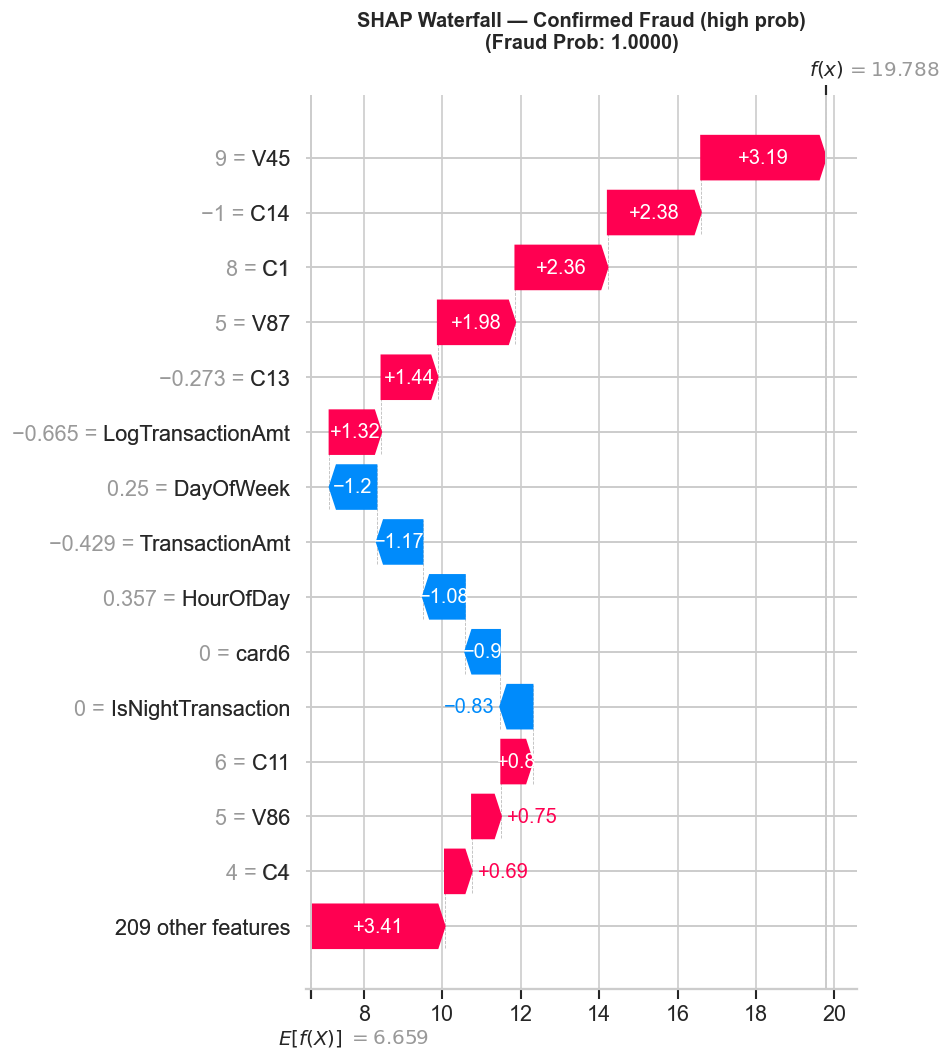

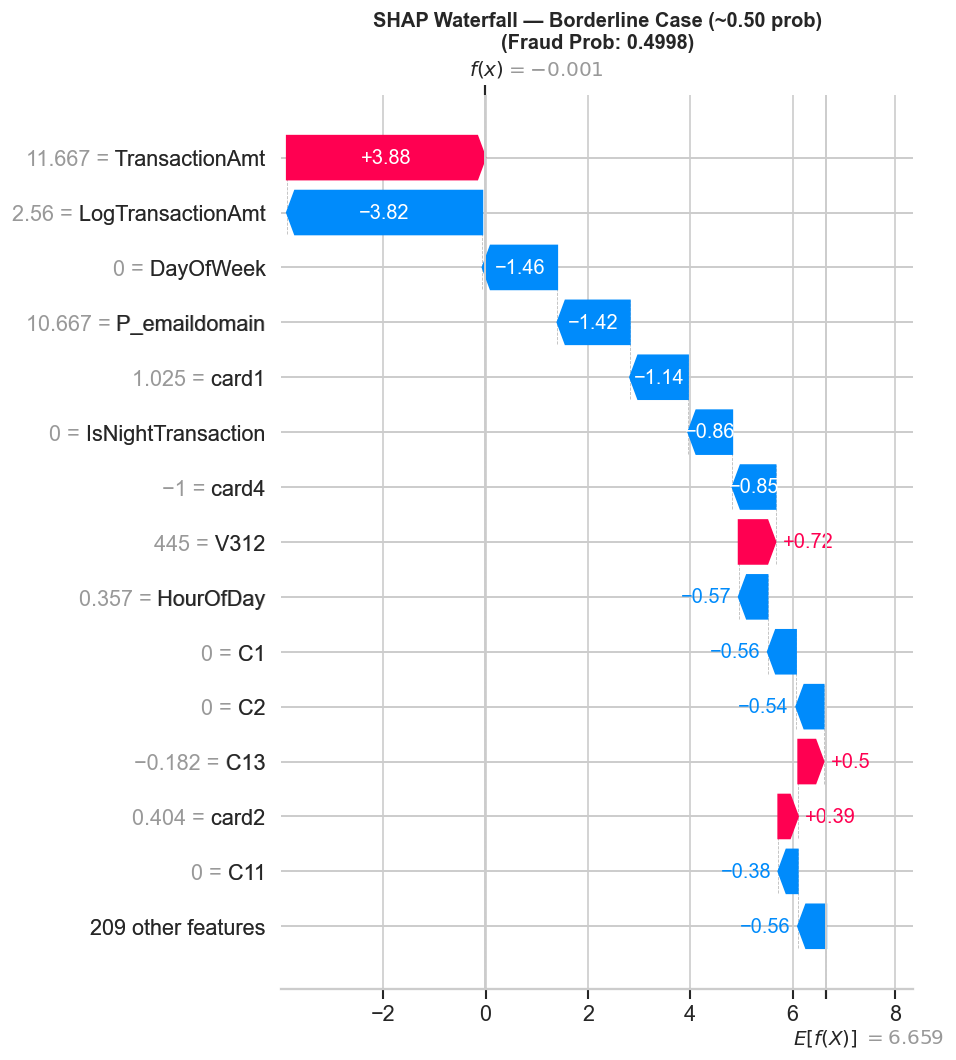

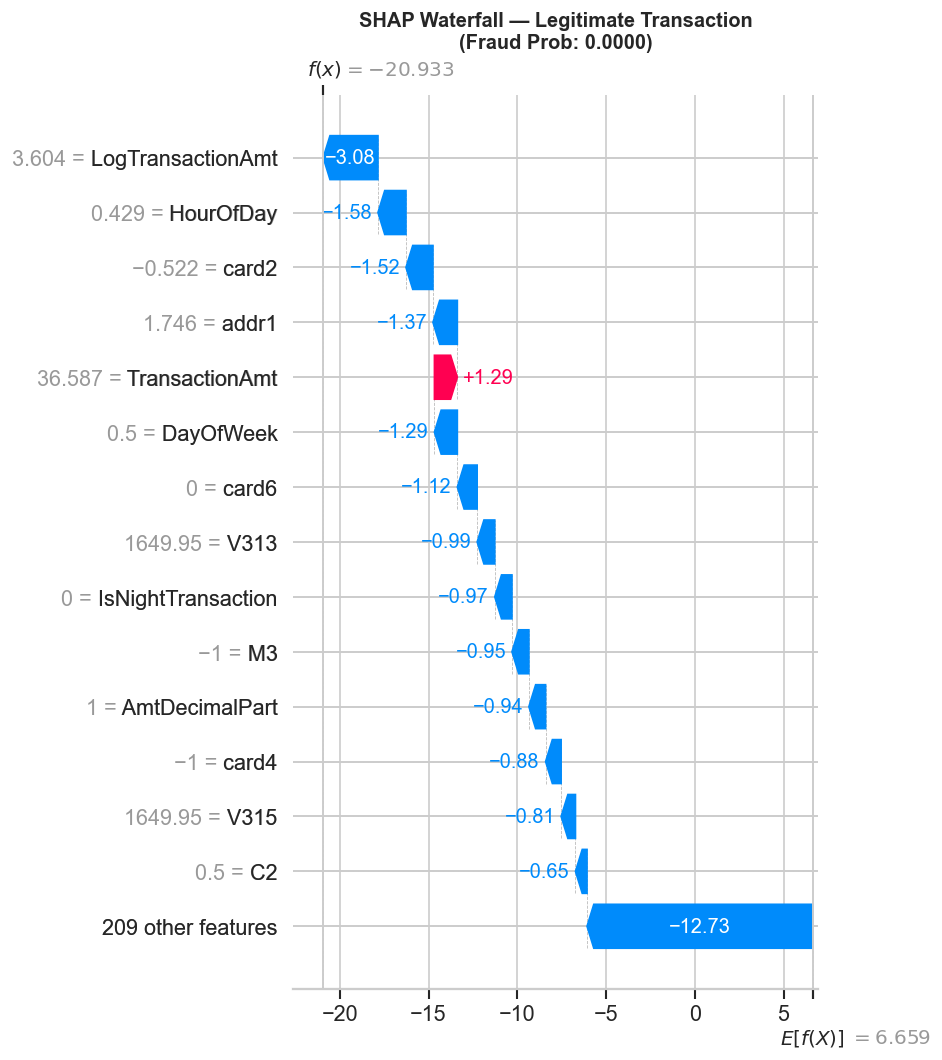

In [36]:
# ── Waterfall plots ───────────────────────────────────────────────────────────
X_test_df_full = pd.DataFrame(X_test_scaled, columns=X.columns)

for idx, label, color in cases:
    row       = X_test_df_full.iloc[[idx]]
    sv_row    = explainer.shap_values(row)
    sv_single = sv_row[1][0] if isinstance(sv_row, list) else sv_row[0]
    ev        = explainer.expected_value[1] if isinstance(explainer.expected_value, list) \
                else explainer.expected_value

    expl = shap.Explanation(values=sv_single, base_values=ev,
                            data=row.values[0], feature_names=X.columns.tolist())

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(expl, max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {label}\n(Fraud Prob: {test_probas[idx]:.4f})',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = label.split()[0].lower() + '_waterfall.png'
    plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()

Top feature for dependence plot: DayOfWeek


<Figure size 960x600 with 0 Axes>

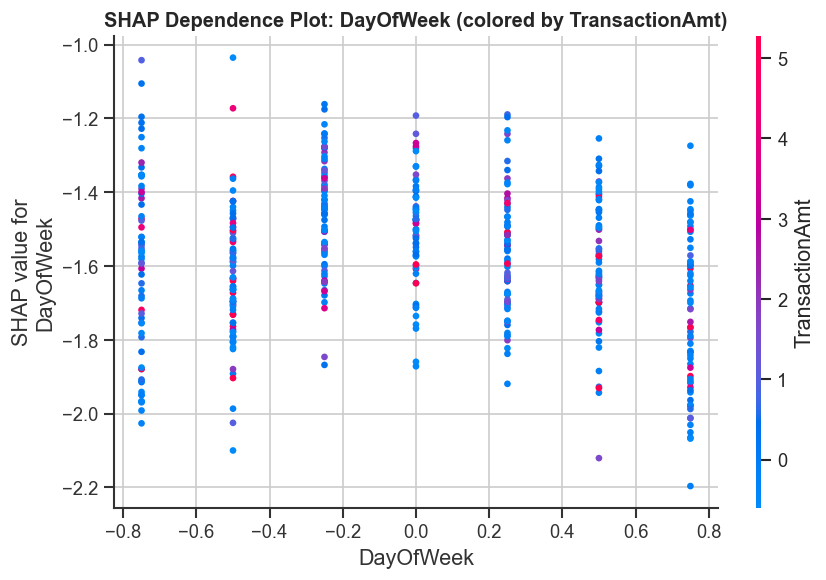

In [37]:
# Find the most important feature by mean absolute SHAP value
mean_shap    = np.abs(sv_fraud).mean(axis=0)
top_feature  = X.columns[np.argmax(mean_shap)]
second_feat  = X.columns[np.argsort(mean_shap)[-2]]

print(f'Top feature for dependence plot: {top_feature}')

plt.figure(figsize=(8, 5))
shap.dependence_plot(top_feature, sv_fraud, X_shap,
                     interaction_index=second_feat, show=False)
plt.title(f'SHAP Dependence Plot: {top_feature} (colored by {second_feat})',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence.png', bbox_inches='tight', dpi=150)
plt.show()

In [39]:
def explain_transaction_plaintext(idx, label, proba, shap_vals, feature_names, top_n=5):
    """Generate plain-English explanation from SHAP values."""
    print(f"\n{'='*60}")
    print(f'TRANSACTION: {label}')
    print(f'Fraud Probability: {proba:.4f} ({"HIGH RISK" if proba>0.5 else "LOW RISK"})')
    print(f"{'='*60}")

    # Top features driving prediction
    sorted_idx = np.argsort(np.abs(shap_vals))[::-1][:top_n]

    increasing = [feature_names[i] for i in sorted_idx if shap_vals[i] > 0]
    decreasing = [feature_names[i] for i in sorted_idx if shap_vals[i] < 0]

    print('\n[Factors INCREASING fraud probability:]')
    for feat in increasing:
        fi = list(feature_names).index(feat)
        print(f'  + {feat}: SHAP = {shap_vals[fi]:+.4f}')

    print('\n[Factors DECREASING fraud probability:]')
    for feat in decreasing:
        fi = list(feature_names).index(feat)
        print(f'  - {feat}: SHAP = {shap_vals[fi]:+.4f}')

    if proba > 0.75:
        verdict = 'BLOCK — This transaction shows multiple strong fraud indicators.'
    elif proba > 0.40:
        verdict = 'FLAG FOR REVIEW — Borderline case, manual analyst review recommended.'
    else:
        verdict = 'CLEAR — Transaction profile consistent with normal customer behavior.'

    print(f'\nACTION: {verdict}')


# Run explanations
for idx, label, _ in cases:
    row    = X_test_df_full.iloc[[idx]]
    sv_row = explainer.shap_values(row)
    sv     = sv_row[1][0] if isinstance(sv_row, list) else sv_row[0]
    explain_transaction_plaintext(idx, label, test_probas[idx], sv, X.columns.tolist())


TRANSACTION: Confirmed Fraud (high prob)
Fraud Probability: 1.0000 (HIGH RISK)

[Factors INCREASING fraud probability:]
  + V45: SHAP = +3.1879
  + C14: SHAP = +2.3790
  + C1: SHAP = +2.3564
  + V87: SHAP = +1.9772
  + C13: SHAP = +1.4365

[Factors DECREASING fraud probability:]

ACTION: BLOCK — This transaction shows multiple strong fraud indicators.

TRANSACTION: Borderline Case (~0.50 prob)
Fraud Probability: 0.4998 (LOW RISK)

[Factors INCREASING fraud probability:]
  + TransactionAmt: SHAP = +3.8836

[Factors DECREASING fraud probability:]
  - LogTransactionAmt: SHAP = -3.8232
  - DayOfWeek: SHAP = -1.4632
  - P_emaildomain: SHAP = -1.4186
  - card1: SHAP = -1.1368

ACTION: FLAG FOR REVIEW — Borderline case, manual analyst review recommended.

TRANSACTION: Legitimate Transaction
Fraud Probability: 0.0000 (LOW RISK)

[Factors INCREASING fraud probability:]
  + TransactionAmt: SHAP = +1.2920

[Factors DECREASING fraud probability:]
  - LogTransactionAmt: SHAP = -3.0847
  - HourOfDa

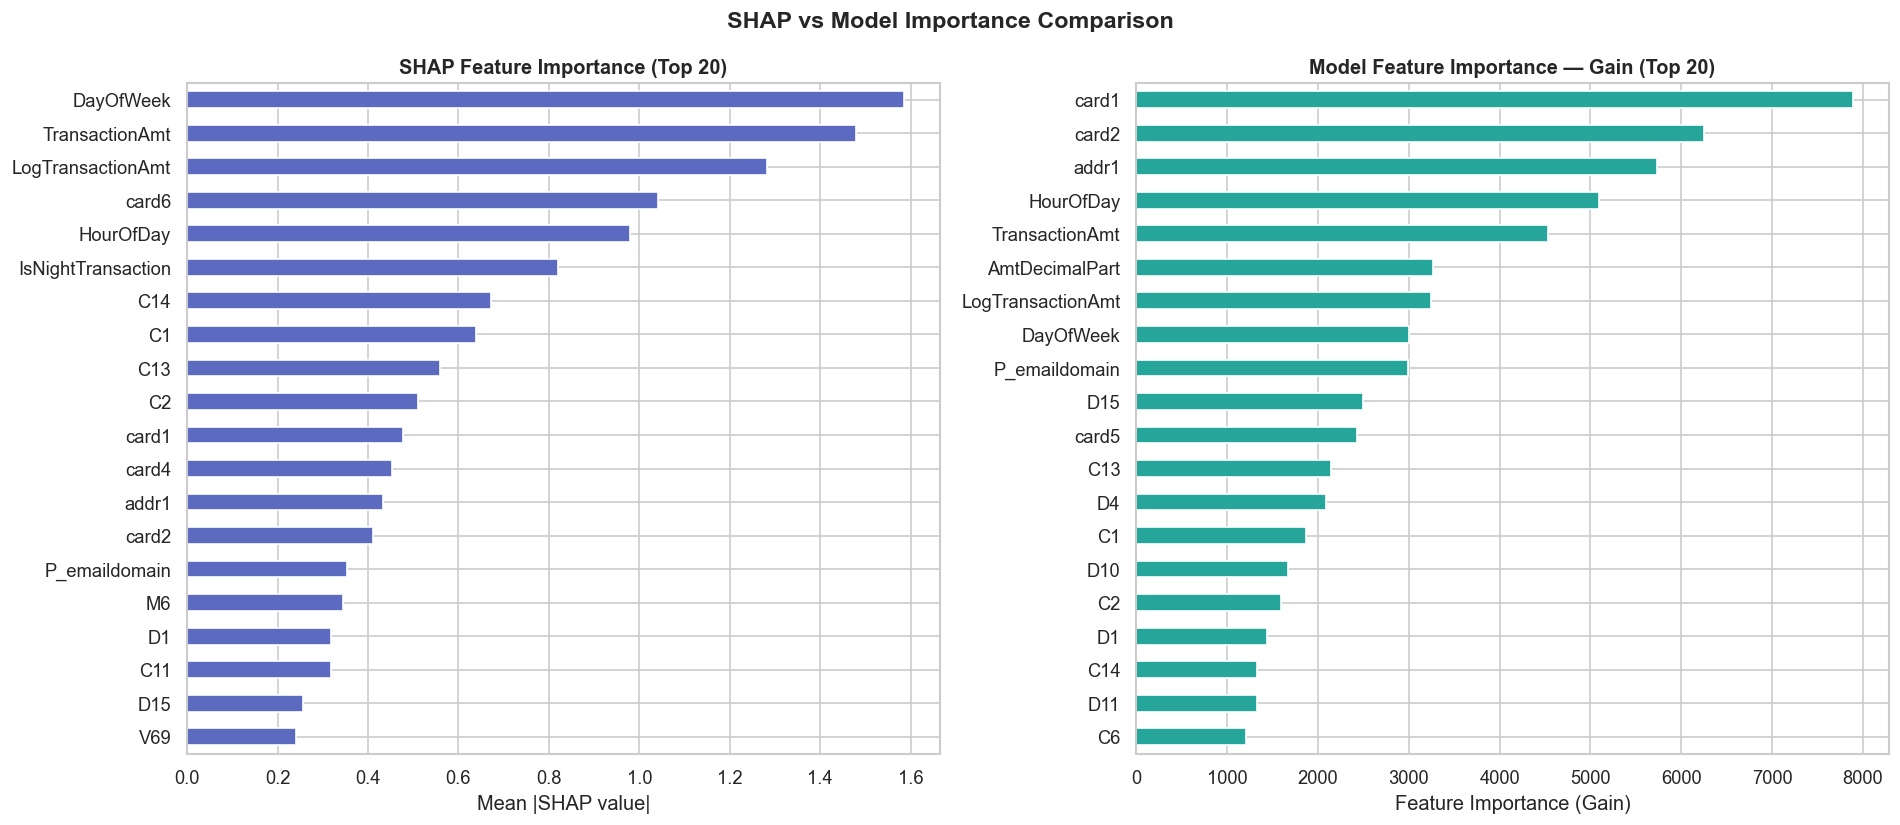

In [40]:
# SHAP importance
shap_importance = pd.Series(
    np.abs(sv_fraud).mean(axis=0),
    index=X.columns
).sort_values(ascending=False).head(20)

# Model (gain) importance
model_importance = pd.Series(
    lgbm_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

shap_importance.sort_values().plot(kind='barh', ax=axes[0],
    color='#5C6BC0', edgecolor='white')
axes[0].set_title('SHAP Feature Importance (Top 20)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean |SHAP value|')

model_importance.sort_values().plot(kind='barh', ax=axes[1],
    color='#26A69A', edgecolor='white')
axes[1].set_title('Model Feature Importance — Gain (Top 20)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature Importance (Gain)')

plt.suptitle('SHAP vs Model Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_vs_model_importance.png', bbox_inches='tight', dpi=150)
plt.show()

In [41]:
# ── Attach predictions back to original test data ─────────────────────────────
test_results = X_test.copy().reset_index(drop=True)
test_results['isFraud']      = y_test.values
test_results['fraud_prob']   = test_probas
test_results['fraud_pred']   = lgbm_pred_opt

# ── Assign risk tiers ──────────────────────────────────────────────────────────
def assign_tier(p):
    if p >= 0.75:  return 'Critical'
    elif p >= 0.40: return 'Suspicious'
    else:           return 'Clear'

test_results['RiskTier'] = test_results['fraud_prob'].apply(assign_tier)
tier_order = ['Critical', 'Suspicious', 'Clear']
tier_colors = {'Critical': '#F44336', 'Suspicious': '#FF9800', 'Clear': '#4CAF50'}

# ── Tier summary ───────────────────────────────────────────────────────────────
tier_summary = test_results.groupby('RiskTier').agg(
    Count          = ('fraud_prob', 'count'),
    True_Frauds    = ('isFraud', 'sum'),
    Avg_Fraud_Prob = ('fraud_prob', 'mean'),
    Avg_Amt        = ('TransactionAmt', 'mean'),
).reindex(tier_order)
tier_summary['Fraud_Rate%'] = (tier_summary['True_Frauds'] / tier_summary['Count'] * 100).round(2)

print('=== RISK TIER SUMMARY ===')
display(tier_summary.style.format({'Avg_Fraud_Prob': '{:.3f}', 'Avg_Amt': '${:.2f}', 'Fraud_Rate%': '{:.2f}%'}))

=== RISK TIER SUMMARY ===


,Count,True_Frauds,Avg_Fraud_Prob,Avg_Amt,Fraud_Rate%
RiskTier,,,,,
Critical,3420,2859,0.954,$140.79,83.60%
Suspicious,2060,410,0.552,$160.48,19.90%
Clear,112628,864,0.023,$134.20,0.77%


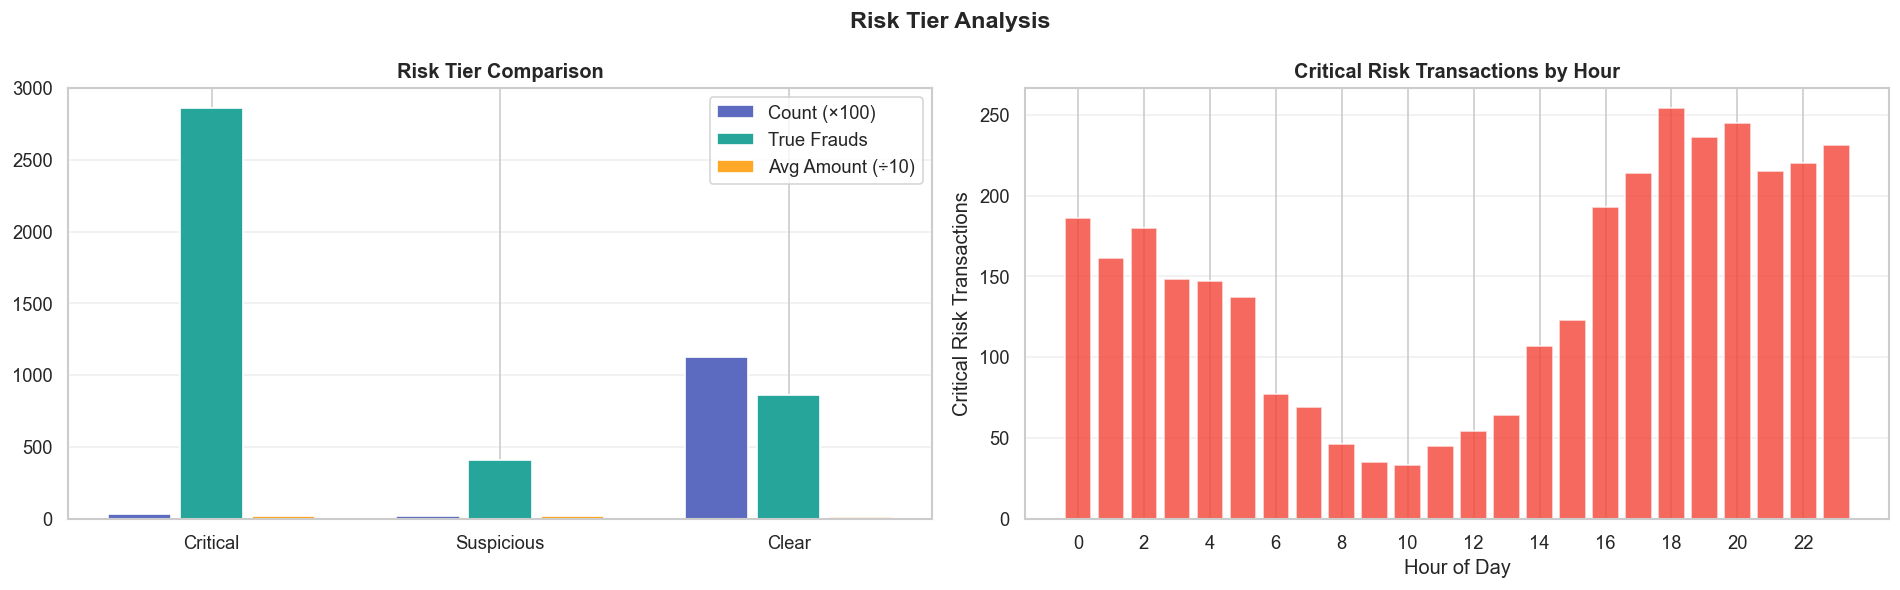

In [42]:
# ── Hour-of-day pattern by tier ───────────────────────────────────────────────
hour_tier = test_results.groupby(['HourOfDay', 'RiskTier']).size().unstack(fill_value=0)
hour_tier = hour_tier[['Critical', 'Suspicious', 'Clear']]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Grouped bar chart: tier comparison
x = np.arange(len(tier_order))
width = 0.25
metrics_plot = {
    'Count (×100)':       tier_summary['Count'] / 100,
    'True Frauds':        tier_summary['True_Frauds'],
    'Avg Amount (÷10)':   tier_summary['Avg_Amt'] / 10
}
offsets = [-0.25, 0, 0.25]
cmap = ['#5C6BC0', '#26A69A', '#FFA726']
for i, (metric, vals) in enumerate(metrics_plot.items()):
    axes[0].bar(x + offsets[i], vals.values, width=0.22, label=metric,
                color=cmap[i], edgecolor='white')
axes[0].set_xticks(x); axes[0].set_xticklabels(tier_order)
axes[0].set_title('Risk Tier Comparison', fontsize=12, fontweight='bold')
axes[0].legend(); axes[0].grid(axis='y', alpha=0.3)

# Hour-of-day fraud rate
hour_fraud = test_results[test_results['RiskTier'] == 'Critical'].groupby('HourOfDay').size()
hour_fraud = hour_fraud.reindex(range(24), fill_value=0)
axes[1].bar(range(24), hour_fraud.values, color='#F44336', edgecolor='white', alpha=0.8)
axes[1].set_xlabel('Hour of Day'); axes[1].set_ylabel('Critical Risk Transactions')
axes[1].set_title('Critical Risk Transactions by Hour', fontsize=12, fontweight='bold')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Risk Tier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_tier_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

In [43]:
# ── Top 3 Fraud Patterns from Critical Risk ────────────────────────────────────
critical = test_results[test_results['RiskTier'] == 'Critical']
true_critical = critical[critical['isFraud'] == 1]

print('=== TOP 3 FRAUD PATTERNS — CRITICAL RISK TRANSACTIONS ===')

print('\nPattern 1: Transaction Amount Distribution')
print(true_critical['TransactionAmt'].describe().round(2))

print('\nPattern 2: Hour of Day (top 5 hours)')
print(true_critical['HourOfDay'].value_counts().head(5))

if 'DeviceType' in true_critical.columns:
    print('\nPattern 3: Device Type Distribution')
    print(true_critical['DeviceType'].value_counts())
else:
    print('\nPattern 3: Night Transaction Flag')
    print(true_critical['IsNightTransaction'].value_counts(normalize=True).round(3))

# Save test_results for Streamlit
test_results.to_csv('test_results.csv', index=False)
print('\ntest_results.csv saved for Streamlit dashboard.')

=== TOP 3 FRAUD PATTERNS — CRITICAL RISK TRANSACTIONS ===

Pattern 1: Transaction Amount Distribution
count   2859.0000
mean     141.1000
std      219.8700
min        0.2900
25%       32.6500
50%       65.9500
75%      150.0000
max     3191.0000
Name: TransactionAmt, dtype: float64

Pattern 2: Hour of Day (top 5 hours)
HourOfDay
18    216
19    207
20    200
23    192
22    175
Name: count, dtype: int64

Pattern 3: Night Transaction Flag
IsNightTransaction
0   0.6480
1   0.3520
Name: proportion, dtype: float64

test_results.csv saved for Streamlit dashboard.


In [44]:
# ── Top 3 Fraud Patterns from Critical Risk ────────────────────────────────────
critical = test_results[test_results['RiskTier'] == 'Critical']
true_critical = critical[critical['isFraud'] == 1]

print('=== TOP 3 FRAUD PATTERNS — CRITICAL RISK TRANSACTIONS ===')

print('\nPattern 1: Transaction Amount Distribution')
print(true_critical['TransactionAmt'].describe().round(2))

print('\nPattern 2: Hour of Day (top 5 hours)')
print(true_critical['HourOfDay'].value_counts().head(5))

if 'DeviceType' in true_critical.columns:
    print('\nPattern 3: Device Type Distribution')
    print(true_critical['DeviceType'].value_counts())
else:
    print('\nPattern 3: Night Transaction Flag')
    print(true_critical['IsNightTransaction'].value_counts(normalize=True).round(3))

# Save test_results for Streamlit
test_results.to_csv('test_results.csv', index=False)
print('\ntest_results.csv saved for Streamlit dashboard.')

=== TOP 3 FRAUD PATTERNS — CRITICAL RISK TRANSACTIONS ===

Pattern 1: Transaction Amount Distribution
count   2859.0000
mean     141.1000
std      219.8700
min        0.2900
25%       32.6500
50%       65.9500
75%      150.0000
max     3191.0000
Name: TransactionAmt, dtype: float64

Pattern 2: Hour of Day (top 5 hours)
HourOfDay
18    216
19    207
20    200
23    192
22    175
Name: count, dtype: int64

Pattern 3: Night Transaction Flag
IsNightTransaction
0   0.6480
1   0.3520
Name: proportion, dtype: float64

test_results.csv saved for Streamlit dashboard.


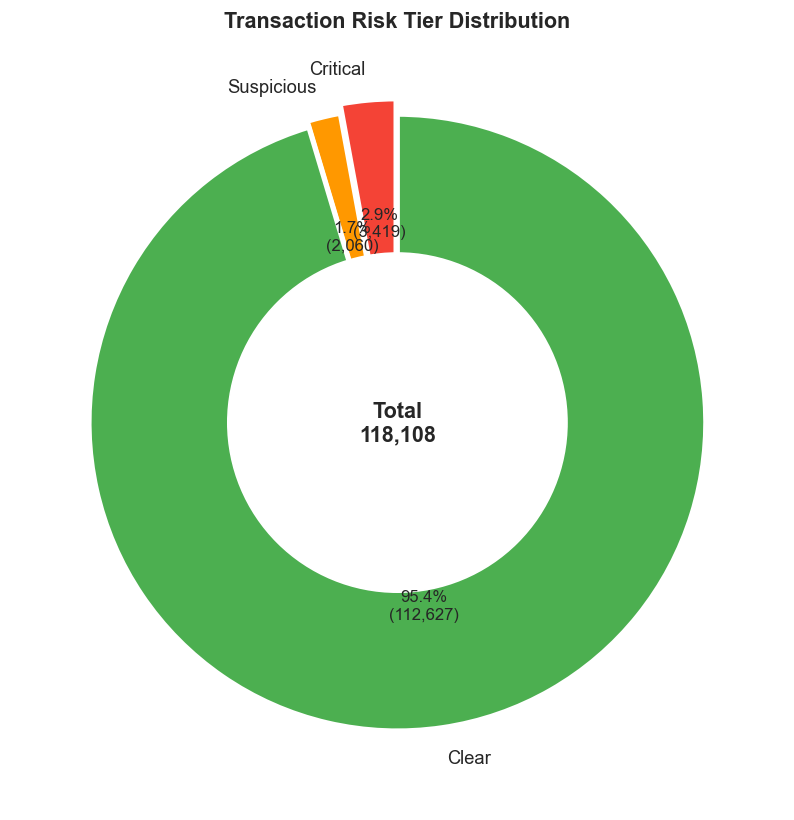

In [45]:
tier_counts = test_results['RiskTier'].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(7, 7))
wedge_props = {'linewidth': 3, 'edgecolor': 'white'}
wedges, texts, autotexts = ax.pie(
    tier_counts.values,
    labels=tier_counts.index,
    autopct=lambda p: f'{p:.1f}%\n({int(p*tier_counts.sum()/100):,})',
    colors=[tier_colors[t] for t in tier_order],
    startangle=90, explode=(0.05, 0.02, 0),
    wedgeprops=wedge_props
)
for at in autotexts:
    at.set_fontsize(10)

# Donut hole
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
ax.add_patch(centre_circle)
ax.text(0, 0, f'Total\n{tier_counts.sum():,}', ha='center', va='center',
        fontsize=13, fontweight='bold')

ax.set_title('Transaction Risk Tier Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('risk_donut.png', bbox_inches='tight', dpi=150)
plt.show()

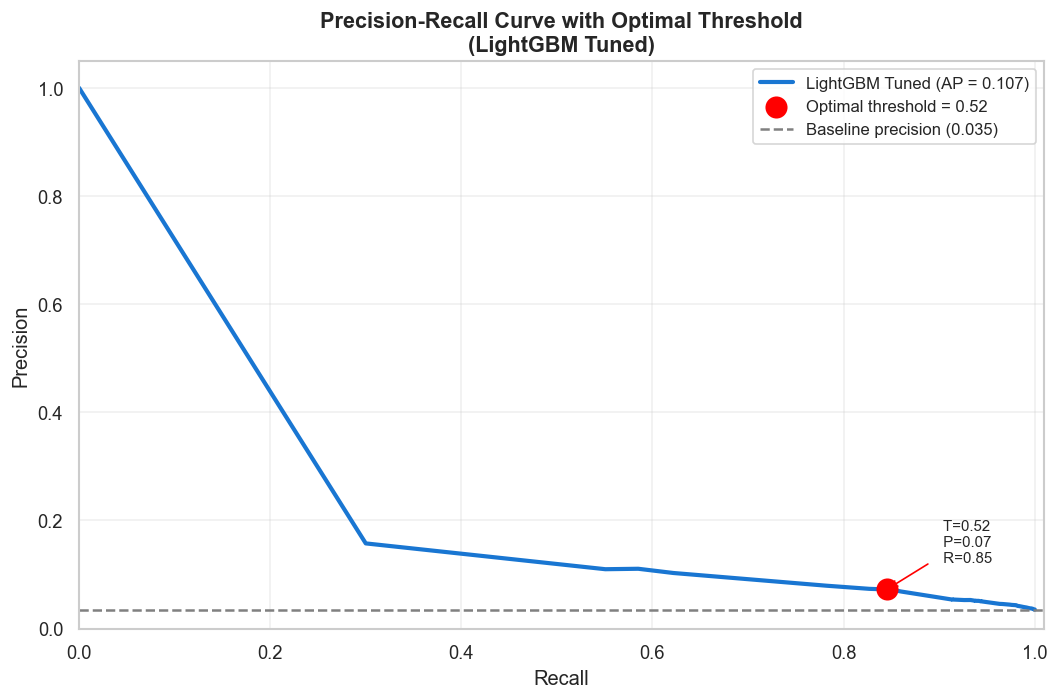

In [46]:
prec_curve, rec_curve, thresh_curve = precision_recall_curve(y_test, lgbm_proba)
pr_auc = average_precision_score(y_test, lgbm_proba)

# Find index for optimal threshold
opt_idx = np.argmin(np.abs(thresh_curve - best_threshold))

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(rec_curve, prec_curve, color='#1976D2', lw=2.5,
        label=f'LightGBM Tuned (AP = {pr_auc:.3f})')
ax.scatter(rec_curve[opt_idx], prec_curve[opt_idx], s=150,
           color='red', zorder=5,
           label=f'Optimal threshold = {best_threshold:.2f}')
ax.axhline(y_test.mean(), color='gray', linestyle='--',
           label=f'Baseline precision ({y_test.mean():.3f})')
ax.annotate(f'  T={best_threshold:.2f}\n  P={prec_curve[opt_idx]:.2f}\n  R={rec_curve[opt_idx]:.2f}',
            xy=(rec_curve[opt_idx], prec_curve[opt_idx]),
            xytext=(rec_curve[opt_idx]+0.05, prec_curve[opt_idx]+0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='red'))
ax.set_xlabel('Recall', fontsize=12); ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve with Optimal Threshold\n(LightGBM Tuned)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1.01]); ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.savefig('pr_curve_optimal.png', bbox_inches='tight', dpi=150)
plt.show()

In [47]:
# Sample for performance
scatter_df = test_results.sample(5000, random_state=42).copy()
scatter_df['Fraud Probability'] = scatter_df['fraud_prob'].round(3)

fig = px.scatter(
    scatter_df,
    x='HourOfDay',
    y='TransactionAmt',
    color='Fraud Probability',
    color_continuous_scale='RdYlGn_r',
    hover_data=['isFraud', 'RiskTier', 'Fraud Probability'],
    log_y=True,
    opacity=0.6,
    title='Transaction Amount vs Hour of Day (colored by Fraud Probability)',
    labels={'HourOfDay': 'Hour of Day', 'TransactionAmt': 'Transaction Amount (log)'}
)
fig.update_layout(width=900, height=500)
fig.show()

In [48]:
# ── Final model summary printout ──────────────────────────────────────────────
print('=' * 60)
print('CAPSTONE PROJECT — FINAL MODEL SUMMARY')
print('=' * 60)
final = pd.DataFrame([res_lgbm, res_xgb, res_if, res_tuned]).set_index('Model')
display(final)

print('\n== Saved Artifacts ==')
for f in ['lgbm_model.pkl', 'xgb_model.pkl', 'scaler.pkl',
          'shap_explainer.pkl', 'feature_names.pkl', 'test_results.csv']:
    exists = os.path.exists(f)
    print(f'  {"✓" if exists else "✗"} {f}')

CAPSTONE PROJECT — FINAL MODEL SUMMARY


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM,0.2511,0.0437,0.9758,0.0836,0.7907,0.1074
XGBoost,0.8490,0.1697,0.8514,0.2829,0.9243,0.5913
Isolation Forest,0.9439,0.1996,0.2001,0.1999,0.7229,0.1174
LightGBM (Tuned),0.9793,0.6840,0.7593,0.7196,0.9613,0.8016



== Saved Artifacts ==
  ✓ lgbm_model.pkl
  ✓ xgb_model.pkl
  ✓ scaler.pkl
  ✓ shap_explainer.pkl
  ✓ feature_names.pkl
  ✓ test_results.csv
